# 7b. Supervised Learning — Customer Churn Prediction

This section addresses the predictive question:

> **Can the available customer characteristics be used to identify customers who are likely to churn?**

The target is binary (`Churn = 1` for a customer who left and `0` otherwise). We compare:

1. A **dummy majority-class classifier** as a minimum baseline.
2. **Logistic Regression**, selected as an interpretable linear probability classifier.
3. **Random Forest**, selected to capture nonlinearities and interactions.

All preprocessing is included inside Scikit-learn pipelines. Model selection is performed only on the training sample using stratified five-fold cross-validation. The held-out test set is used once for final evaluation.

## 7b.1 Imports and reproducibility

A fixed random seed is used so that the split and model results can be reproduced by all team members.

In [1]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20
warnings.filterwarnings("ignore", category=FutureWarning)

## 7b.2 Load and prepare the analytical dataset

The code first searches for a local CSV. If none is available, it downloads the same Kaggle dataset used in the group notebook.

Only the following preprocessing is performed before the train/test split:

- Convert `TotalCharges` to numeric.
- Remove the 11 rows where `TotalCharges` is blank.
- Convert `Churn` to a binary target.
- Remove `customerID`, because it is an identifier rather than a meaningful predictor.

The original categories such as `No internet service` are retained. For prediction, these categories can contain information that differs from a simple `No` response.

In [2]:
# Reuse an existing group dataframe when this section is copied into the master notebook.
if "df" in globals() and isinstance(df, pd.DataFrame) and {"Churn", "TotalCharges"}.issubset(df.columns):
    model_df = df.copy()
    data_source = "existing dataframe named df"
else:
    candidate_paths = [
        Path("data/WA_Fn-UseC_-Telco-Customer-Churn.csv"),
        Path("WA_Fn-UseC_-Telco-Customer-Churn.csv"),
        Path("data/Telco-Customer-Churn.csv"),
        Path("Telco-Customer-Churn.csv"),
        Path("/mnt/data/Telco-Customer-Churn.csv"),
    ]
    csv_path = next((p for p in candidate_paths if p.exists()), None)

    if csv_path is None:
        import kagglehub
        kaggle_path = kagglehub.dataset_download("blastchar/telco-customer-churn")
        csv_path = Path(kaggle_path) / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

    model_df = pd.read_csv(csv_path)
    data_source = str(csv_path)

# Standardize the target column in case the master notebook already created Churn_Numeric.
model_df["TotalCharges"] = pd.to_numeric(model_df["TotalCharges"], errors="coerce")
model_df = model_df.dropna(subset=["TotalCharges"]).copy()

if "Churn_Numeric" in model_df.columns:
    y = model_df["Churn_Numeric"].astype(int)
else:
    y = model_df["Churn"].map({"Yes": 1, "No": 0}).astype(int)

columns_to_drop = [c for c in ["customerID", "Churn", "Churn_Numeric"] if c in model_df.columns]
X = model_df.drop(columns=columns_to_drop)

print(f"Data source: {data_source}")
print(f"Analytical sample: {X.shape[0]:,} customers")
print(f"Predictors before encoding: {X.shape[1]}")
print(f"Churn rate: {y.mean():.3f}")

Data source: Telco-Customer-Churn.csv
Analytical sample: 7,032 customers
Predictors before encoding: 19
Churn rate: 0.266


## 7b.3 Train/test split and preprocessing

Because churn is less common than non-churn, `stratify=y` preserves approximately the same class distribution in the training and test sets.

The preprocessing pipeline is fitted separately inside every cross-validation fold:

- Numeric features: median imputation followed by standardization.
- Categorical features: most-frequent imputation followed by one-hot encoding.

This design prevents information from the validation or test observations from leaking into the training process.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

print(f"Training observations: {len(X_train):,}")
print(f"Test observations: {len(X_test):,}")
print(f"Training churn rate: {y_train.mean():.3f}")
print(f"Test churn rate: {y_test.mean():.3f}")
print(f"Numeric variables: {len(numeric_features)}")
print(f"Categorical variables: {len(categorical_features)}")

Training observations: 5,625
Test observations: 1,407
Training churn rate: 0.266
Test churn rate: 0.266
Numeric variables: 4
Categorical variables: 15


## 7b.4 Model selection with stratified cross-validation

The majority-class dummy classifier shows what can be achieved without learning any useful customer pattern. Since approximately 73% of customers do not churn, this baseline can obtain deceptively high accuracy while identifying none of the churners.

For Logistic Regression and Random Forest, a small and transparent parameter grid is evaluated using five-fold stratified cross-validation. `ROC-AUC` is the model-selection criterion because it evaluates ranking performance across thresholds. Recall, precision, F1, PR-AUC, and accuracy are also reported.

`class_weight="balanced"` gives additional weight to the minority churn class during training.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "accuracy": "accuracy",
}

# 1) Dummy baseline
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyClassifier(strategy="most_frequent")),
    ]
)

baseline_cv = cross_validate(
    baseline_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
)

# 2) Logistic Regression
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=3000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid={"model__C": [0.1, 1.0, 5.0]},
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    n_jobs=1,
    return_train_score=False,
)
logistic_grid.fit(X_train, y_train)

# 3) Random Forest
forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
        ),
    ]
)

forest_grid = GridSearchCV(
    estimator=forest_pipeline,
    param_grid={
        "model__n_estimators": [200],
        "model__max_depth": [6, 10],
        "model__min_samples_leaf": [1, 4],
        "model__max_features": ["sqrt"],
    },
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    n_jobs=1,
    return_train_score=False,
)
forest_grid.fit(X_train, y_train)

print("Best Logistic Regression parameters:", logistic_grid.best_params_)
print("Best Random Forest parameters:", forest_grid.best_params_)

Best Logistic Regression parameters: {'model__C': 5.0}
Best Random Forest parameters: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__n_estimators': 200}


In [5]:
def best_cv_row(search, model_name):
    i = search.best_index_
    return {
        "Model": model_name,
        "ROC-AUC": search.cv_results_["mean_test_roc_auc"][i],
        "PR-AUC": search.cv_results_["mean_test_pr_auc"][i],
        "Precision": search.cv_results_["mean_test_precision"][i],
        "Recall": search.cv_results_["mean_test_recall"][i],
        "F1": search.cv_results_["mean_test_f1"][i],
        "Accuracy": search.cv_results_["mean_test_accuracy"][i],
    }

cv_results = pd.DataFrame(
    [
        {
            "Model": "Dummy baseline",
            **{
                label: baseline_cv[f"test_{key}"].mean()
                for label, key in [
                    ("ROC-AUC", "roc_auc"),
                    ("PR-AUC", "pr_auc"),
                    ("Precision", "precision"),
                    ("Recall", "recall"),
                    ("F1", "f1"),
                    ("Accuracy", "accuracy"),
                ]
            },
        },
        best_cv_row(logistic_grid, "Logistic Regression"),
        best_cv_row(forest_grid, "Random Forest"),
    ]
).set_index("Model")

cv_results.round(3)

,ROC-AUC,PR-AUC,Precision,Recall,F1,Accuracy
Model,,,,,,
Dummy baseline,0.500,0.266,0.000,0.000,0.000,0.734
Logistic Regression,0.846,0.658,0.519,0.802,0.630,0.750
Random Forest,0.847,0.664,0.558,0.742,0.637,0.775


### Cross-validation interpretation

The dummy model demonstrates why accuracy alone is inappropriate: it predicts every customer as a non-churner, producing an accuracy close to the majority-class share but zero recall and zero F1 for the churn class.

Both trained models should substantially outperform this baseline in ROC-AUC and PR-AUC. Logistic Regression is expected to provide a strong and interpretable benchmark, while Random Forest can improve performance when nonlinearities and interactions are important.

## 7b.5 Final evaluation on the held-out test set

The test sample was not used during parameter selection. Each selected pipeline is now evaluated once on this sample.

The positive class is churn (`1`). Therefore:

- **Recall**: proportion of actual churners successfully identified.
- **Precision**: proportion of predicted churners who actually churned.
- **F1**: harmonic mean of precision and recall.
- **ROC-AUC**: ability to rank churners above non-churners across thresholds.
- **PR-AUC**: precision-recall performance, particularly informative for the minority churn class.

In [6]:
final_models = {
    "Dummy baseline": baseline_pipeline.fit(X_train, y_train),
    "Logistic Regression": logistic_grid.best_estimator_,
    "Random Forest": forest_grid.best_estimator_,
}

predictions = {}
test_rows = []

for model_name, fitted_model in final_models.items():
    y_pred = fitted_model.predict(X_test)
    y_probability = fitted_model.predict_proba(X_test)[:, 1]
    predictions[model_name] = (y_pred, y_probability)

    test_rows.append(
        {
            "Model": model_name,
            "ROC-AUC": roc_auc_score(y_test, y_probability),
            "PR-AUC": average_precision_score(y_test, y_probability),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1": f1_score(y_test, y_pred, zero_division=0),
            "Accuracy": accuracy_score(y_test, y_pred),
        }
    )

test_results = pd.DataFrame(test_rows).set_index("Model")
test_results.round(3)

,ROC-AUC,PR-AUC,Precision,Recall,F1,Accuracy
Model,,,,,,
Dummy baseline,0.500,0.266,0.000,0.000,0.000,0.734
Logistic Regression,0.835,0.617,0.490,0.797,0.607,0.726
Random Forest,0.833,0.639,0.531,0.762,0.626,0.758


In [7]:
for model_name in ["Logistic Regression", "Random Forest"]:
    y_pred, _ = predictions[model_name]
    print("=" * 70)
    print(model_name)
    print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"], digits=3))

Logistic Regression
              precision    recall  f1-score   support

      Stayed      0.905     0.700     0.789      1033
     Churned      0.490     0.797     0.607       374

    accuracy                          0.726      1407
   macro avg      0.698     0.748     0.698      1407
weighted avg      0.795     0.726     0.741      1407

Random Forest
              precision    recall  f1-score   support

      Stayed      0.898     0.756     0.821      1033
     Churned      0.531     0.762     0.626       374

    accuracy                          0.758      1407
   macro avg      0.714     0.759     0.723      1407
weighted avg      0.800     0.758     0.769      1407



## 7b.6 Confusion matrices

The confusion matrix separates four outcomes:

- True negative: correctly predicted that the customer stayed.
- False positive: predicted churn, but the customer stayed.
- False negative: predicted stay, but the customer churned.
- True positive: correctly predicted churn.

For retention campaigns, false negatives are especially costly because these customers leave without being flagged for intervention.

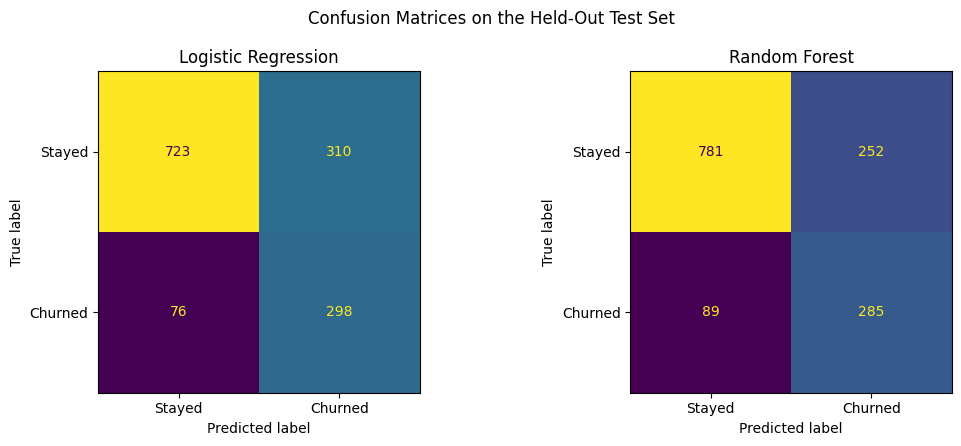

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, model_name in zip(axes, ["Logistic Regression", "Random Forest"]):
    y_pred, _ = predictions[model_name]
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, y_pred),
        display_labels=["Stayed", "Churned"],
    ).plot(ax=ax, colorbar=False)
    ax.set_title(model_name)

plt.suptitle("Confusion Matrices on the Held-Out Test Set")
plt.tight_layout()
plt.show()

## 7b.7 ROC and precision-recall curves

The ROC curve summarizes the trade-off between the true-positive rate and false-positive rate. The precision-recall curve focuses on performance for the positive churn class and is useful under class imbalance.

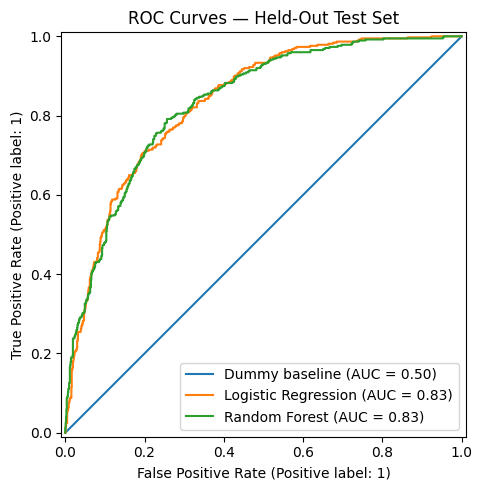

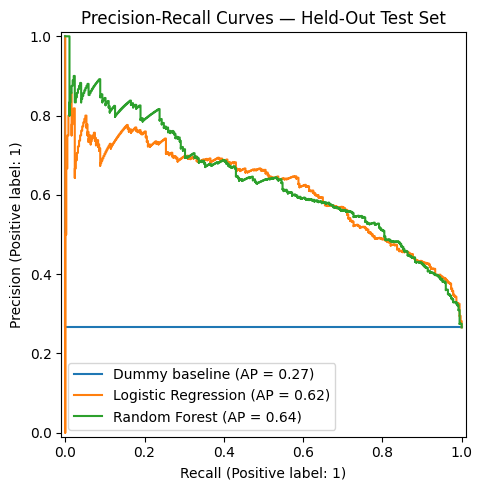

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
for model_name in ["Dummy baseline", "Logistic Regression", "Random Forest"]:
    _, y_probability = predictions[model_name]
    RocCurveDisplay.from_predictions(y_test, y_probability, name=model_name, ax=ax)
ax.set_title("ROC Curves — Held-Out Test Set")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for model_name in ["Dummy baseline", "Logistic Regression", "Random Forest"]:
    _, y_probability = predictions[model_name]
    PrecisionRecallDisplay.from_predictions(y_test, y_probability, name=model_name, ax=ax)
ax.set_title("Precision-Recall Curves — Held-Out Test Set")
plt.tight_layout()
plt.show()

## 7b.8 Model interpretation

For Logistic Regression, positive coefficients increase the estimated log-odds of churn, while negative coefficients decrease them, holding the other encoded variables constant. These are predictive associations and should not be interpreted as causal effects.

For Random Forest, impurity-based feature importance indicates which encoded variables contributed most to the tree splits. It can favor continuous or high-cardinality variables, so it should be treated as descriptive rather than causal evidence.

In [10]:
def cleaned_feature_names(fitted_pipeline):
    names = fitted_pipeline.named_steps["preprocessor"].get_feature_names_out()
    return [
        name.replace("numeric__", "").replace("categorical__", "")
        for name in names
    ]

# Logistic Regression coefficients
logistic_model = final_models["Logistic Regression"]
log_feature_names = cleaned_feature_names(logistic_model)
log_coefficients = logistic_model.named_steps["model"].coef_[0]

logistic_importance = (
    pd.DataFrame({"Feature": log_feature_names, "Coefficient": log_coefficients})
    .assign(AbsoluteCoefficient=lambda x: x["Coefficient"].abs())
    .sort_values("AbsoluteCoefficient", ascending=False)
)

print("Most influential Logistic Regression coefficients:")
display(logistic_importance.head(15).drop(columns="AbsoluteCoefficient").round(3))

# Random Forest feature importances
forest_model = final_models["Random Forest"]
forest_feature_names = cleaned_feature_names(forest_model)
forest_importance = (
    pd.DataFrame(
        {
            "Feature": forest_feature_names,
            "Importance": forest_model.named_steps["model"].feature_importances_,
        }
    )
    .sort_values("Importance", ascending=False)
)

print("Most important Random Forest features:")
display(forest_importance.head(15).round(3))

Most influential Logistic Regression coefficients:


,Feature,Coefficient
2,MonthlyCharges,-1.568
1,tenure,-1.279
16,InternetService_Fiber optic,1.111
15,InternetService_DSL,-0.918
38,Contract_Two year,-0.811
36,Contract_Month-to-month,0.677
3,TotalCharges,0.638
32,StreamingTV_Yes,0.468
35,StreamingMovies_Yes,0.461
17,InternetService_No,-0.454


Most important Random Forest features:


,Feature,Importance
36,Contract_Month-to-month,0.133
1,tenure,0.128
3,TotalCharges,0.099
2,MonthlyCharges,0.072
38,Contract_Two year,0.070
18,OnlineSecurity_No,0.062
27,TechSupport_No,0.050
16,InternetService_Fiber optic,0.046
43,PaymentMethod_Electronic check,0.035
37,Contract_One year,0.020


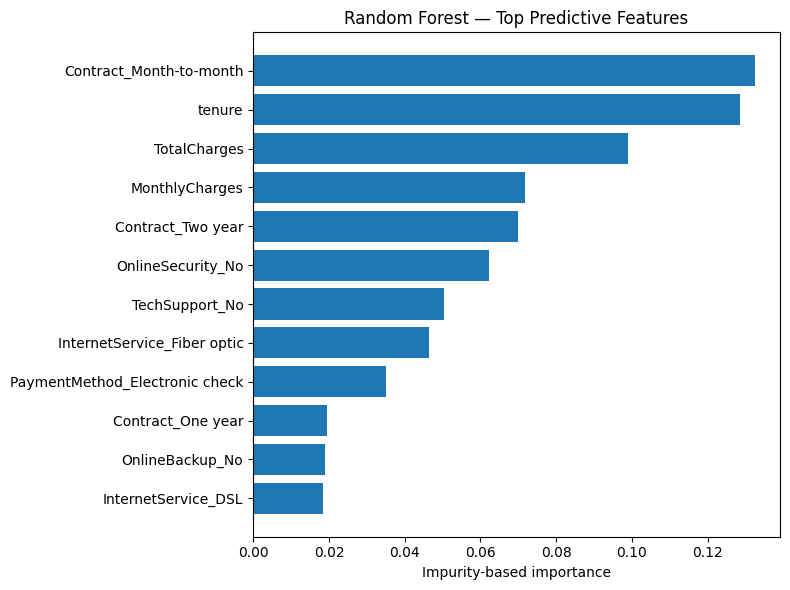

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_data = forest_importance.head(12).sort_values("Importance")
ax.barh(plot_data["Feature"], plot_data["Importance"])
ax.set_title("Random Forest — Top Predictive Features")
ax.set_xlabel("Impurity-based importance")
plt.tight_layout()
plt.show()

## 7b.9 Supervised-learning conclusion

The supervised analysis compares the models against a majority-class baseline and evaluates them using stratified cross-validation and a held-out test set. The dummy baseline obtains seemingly acceptable accuracy by predicting that every customer stays, but it identifies no churners. This confirms that recall, F1, ROC-AUC, and PR-AUC are more informative than accuracy alone.

In the executed analysis, Logistic Regression and Random Forest provide similar ranking performance. Logistic Regression identifies a larger share of actual churners and is therefore attractive when the business priority is to miss as few at-risk customers as possible. Random Forest provides a better balance between precision and recall and produces fewer false alarms. The final operational choice therefore depends on the relative cost of contacting a non-churner versus failing to identify a true churner.

The predictive results do not establish causality. A variable may help predict churn without representing an effective intervention. Questions about whether changing contract type would reduce churn are addressed separately in the causal-inference section.

## Reproducibility note

- Random seed: `42`
- Test size: `20%`
- Cross-validation: stratified five-fold
- Model-selection metric: ROC-AUC
- Positive class: churn (`1`)
- Identifier excluded: `customerID`
- All transformations fitted inside model pipelines